<a href="https://colab.research.google.com/github/ravishchanda/bleep/blob/Dev/linear_regression_practice_100324_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
insurance_data = pd.read_csv('/content/sample_data/new_insurance_data.csv')
insurance_data.head()

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
0,18.0,male,23.21,0.0,no,29087.54313,17.0,715428.0,4720920.992,0.0,55784970.05,southeast,1121.8739
1,18.0,male,30.14,0.0,no,39053.67437,7.0,699157.0,4329831.676,0.0,13700885.19,southeast,1131.5066
2,18.0,male,33.33,0.0,no,39023.62759,19.0,702341.0,6884860.774,0.0,73523107.27,southeast,1135.9407
3,18.0,male,33.66,0.0,no,28185.39332,11.0,700250.0,4274773.550,0.0,75819679.60,southeast,1136.3994
4,18.0,male,34.10,0.0,no,14697.85941,16.0,711584.0,3787293.921,0.0,23012320.01,southeast,1137.0110


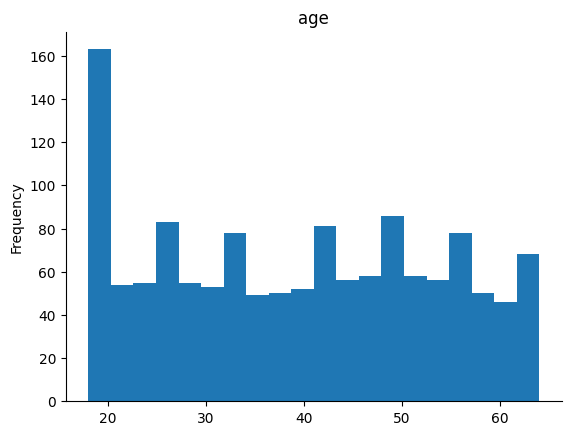

In [4]:
# @title age

from matplotlib import pyplot as plt
insurance_data['age'].plot(kind='hist', bins=20, title='age')
plt.gca().spines[['top', 'right',]].set_visible(False)

After the data load, perform  EDA (Exploratory Data Analysis)

check for shape, column info, null, duplicates, describe, correlations, outliers and then model building.

In [5]:
insurance_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   age                              1329 non-null   float64
 1   sex                              1338 non-null   object 
 2   bmi                              1335 non-null   float64
 3   children                         1333 non-null   float64
 4   smoker                           1338 non-null   object 
 5   Claim_Amount                     1324 non-null   float64
 6   past_consultations               1332 non-null   float64
 7   num_of_steps                     1335 non-null   float64
 8   Hospital_expenditure             1334 non-null   float64
 9   NUmber_of_past_hospitalizations  1336 non-null   float64
 10  Anual_Salary                     1332 non-null   float64
 11  region                           1338 non-null   object 
 12  charges             

In [7]:
insurance_data.shape

(1338, 13)

In [9]:
insurance_data.dtypes

,0
age,float64
sex,object
bmi,float64
children,float64
smoker,object
Claim_Amount,float64
past_consultations,float64
num_of_steps,float64
Hospital_expenditure,float64
NUmber_of_past_hospitalizations,float64


In [11]:
insurance_data.isnull().sum()

,0
age,9
sex,0
bmi,3
children,5
smoker,0
Claim_Amount,14
past_consultations,6
num_of_steps,3
Hospital_expenditure,4
NUmber_of_past_hospitalizations,2


In [13]:
insurance_data[insurance_data.isnull().any(axis=1)]

,age,sex,bmi,children,smoker,Claim_Amount,past_consultations,num_of_steps,Hospital_expenditure,NUmber_of_past_hospitalizations,Anual_Salary,region,charges
5,18.0,male,34.430,0.0,no,26488.339120,20.0,717162.0,3.696161e+06,0.0,NaN,southeast,1137.46970
8,18.0,male,43.010,0.0,no,9715.650411,17.0,NaN,9.216440e+06,0.0,5.888197e+07,southeast,1149.39590
11,19.0,male,20.300,0.0,no,1920.136268,NaN,695430.0,3.786542e+06,0.0,2.747072e+06,southwest,1242.26000
12,19.0,male,20.700,0.0,no,3927.892067,4.0,723928.0,5.013945e+06,NaN,9.462889e+07,southwest,1242.81600
13,19.0,male,27.600,0.0,no,46780.546480,8.0,701227.0,NaN,0.0,3.842163e+07,southwest,1252.40700
15,19.0,male,NaN,0.0,no,12515.953700,15.0,726642.0,2.716158e+06,0.0,4.354445e+07,southwest,1256.29900
16,NaN,male,34.100,0.0,no,14682.871510,3.0,718891.0,1.992862e+06,0.0,2.396534e+07,southwest,1261.44200
19,20.0,male,33.330,0.0,no,12590.767620,14.0,729642.0,7.647247e+06,0.0,NaN,southeast,1391.52870
35,NaN,male,25.175,0.0,no,47840.825560,17.0,727198.0,3.779651e+06,0.0,4.964638e+07,northwest,1632.03625
46,NaN,male,39.500,0.0,no,33218.346350,10.0,752311.0,8.767307e+06,0.0,4.038872e+06,southwest,1682.59700


dropping null values with dropna

In [15]:
insurance_data.dropna(inplace=True)

In [16]:
insurance_data.shape

(1287, 13)

check for duplicates with df.duplicated().sum(()

and remove with df.drop_duplicates(inplace=True)

0

In [18]:
insurance_data.describe(include='object')

,sex,smoker,region
count,1287,1287,1287
unique,2,2,4
top,female,no,southeast
freq,648,1023,347


Rsume Linear REgression Handson 31/05 from 1:11 onwards